## This Notebook Uses ReSNet50 (Transfer Learning with PreTrained Weights and Retraining) Model to generate Output Predictions

#  <font color='red'>Table of Contents</font>


[9. ResNet50 Models](#section9)<br>


In [1]:
# Research Kernel Link - https://github.com/dimitreOliveira/APTOS2019BlindnessDetection/blob/master/Model%20backlog/ResNet50/4%20-%20ResNet50%20-%20Batch%20size%2022.ipynb

import pandas as pd
import numpy as np
import os
from prettytable import PrettyTable
import pickle
import multiprocessing
from multiprocessing.pool import ThreadPool
print(multiprocessing.cpu_count()," CPU cores")

import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["axes.grid"] = False

from sklearn.metrics import confusion_matrix, cohen_kappa_score,accuracy_score

# from PIL import Image
import cv2

from tensorflow.keras import applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers, Model, Sequential
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

16  CPU cores


In [2]:
import tensorflow as tf

print(tf.__version__)
print("GPUs disponibles:", len(tf.config.list_physical_devices('GPU')))

2.10.0
GPUs disponibles: 1


In [ ]:
# Colab Libs...
# from pydrive.auth import GoogleAuth
# from pydrive.drive import GoogleDrive
# from google.colab import auth
# from oauth2client.client import GoogleCredentials

#  <a id = 'section9'> <font color='red'>  9. ResNet50 Models  </font> </a>

### <font color='red'> 9.1 Setup Colab Environment </font>

In [ ]:
# Importing Libraries
#ref - https://buomsoo-kim.github.io/colab/2018/04/16/Importing-files-from-Google-Drive-in-Google-Colab.md/

# auth.authenticate_user()
# gauth = GoogleAuth()
# gauth.credentials = GoogleCredentials.get_application_default()
# drive = GoogleDrive(gauth)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
os.chdir('/content/drive/My Drive/Colab Notebooks')
print("We are currently in the folder of ", os.getcwd())

We are currently in the folder of  /content/drive/My Drive/Colab Notebooks


In [3]:
def load_data():
    file = open('duplicado/df_train', 'rb')
    df_train = pickle.load(file).astype(str)
    file.close()

    file = open('duplicado/df_test', 'rb')
    df_test = pickle.load(file).astype(str)
    file.close()

    return df_train, df_test

In [4]:
df_train, df_test = load_data()
print(df_train.shape, df_test.shape,'\n')
df_train.head(6)

(2848, 4) (712, 4) 



,id_code,diagnosis,file_path,file_name
1123,541db13517e2,2,./train_images/541db13517e2.png,541db13517e2.png
2755,d0079cc188e9,3,./train_images/d0079cc188e9.png,d0079cc188e9.png
1753,870f433e8f37,0,./train_images/870f433e8f37.png,870f433e8f37.png
3533,dbb2c63f6f08,3,./train_images/dbb2c63f6f08.png,dbb2c63f6f08.png
1094,525d0dd8dc45,0,./train_images/525d0dd8dc45.png,525d0dd8dc45.png
394,1e143fa3de57,2,./train_images/1e143fa3de57.png,1e143fa3de57.png


### <font color='red'> 9.2 Image Pre Processing </font>

In [18]:
IMG_SIZE = 512

In [ ]:
def crop_image_from_gray(img,tol=7):
    if img.ndim ==2:
        mask = img>tol
        return img[np.ix_(mask.any(1),mask.any(0))]
    elif img.ndim==3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img>tol

        check_shape = img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0]
        if (check_shape == 0): # image is too dark so that we crop out everything,
            return img # return original image
        else:
            img1=img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
            img2=img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
            img3=img[:,:,2][np.ix_(mask.any(1),mask.any(0))]
    #         print(img1.shape,img2.shape,img3.shape)
            img = np.stack([img1,img2,img3],axis=-1)
    #         print(img.shape)
        return img

def circle_crop(img, sigmaX = 30):
    """
    Create circular crop around image centre
    """
    img = crop_image_from_gray(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    height, width, depth = img.shape

    x = int(width/2)
    y = int(height/2)
    r = np.amin((x,y))

    circle_img = np.zeros((height, width), np.uint8)
    cv2.circle(circle_img, (x,y), int(r), 1, thickness=-1)
    img = cv2.bitwise_and(img, img, mask=circle_img)
    img = crop_image_from_gray(img)
    img=cv2.addWeighted(img,4, cv2.GaussianBlur( img , (0,0) , sigmaX) ,-4 ,128)
    return img

def preprocess_image(file):
    input_filepath = os.path.join('./','test_images_resized',f'{file}.png')
    output_filepath = os.path.join('./','test_images_resized_preprocessed',f'{file}.png')

    img = cv2.imread(input_filepath)
    img = circle_crop(img)
    cv2.imwrite(output_filepath, cv2.resize(img, (IMG_SIZE,IMG_SIZE)))

In [ ]:
'''This Function uses Multi processing for faster saving of images into folder'''

def multiprocess_image_processor(process:int, imgs:list):
    """
    Inputs:
        process: (int) number of process to run
        imgs:(list) list of images
    """
    print(f'MESSAGE: Running {process} process')
    results = ThreadPool(process).map(preprocess_image, imgs)
    return results

In [ ]:
# Use 2 cores (colab)
# ref - https://stackoverflow.com/questions/1006289/how-to-find-out-the-number-of-cpus-using-python

b = multiprocess_image_processor(8, list(df_test.id_code.values))

MESSAGE: Running 8 process


TRAIN (8 nucleos 1m 24.4s) TEST (8 nucleos 48.1s)

### <font color='red'> 9.3 Train Model </font>

In [30]:
# Model parameters
BATCH_SIZE = 8
EPOCHS = 40
WARMUP_EPOCHS = 2
LEARNING_RATE = 1e-4
WARMUP_LEARNING_RATE = 1e-3
HEIGHT = 320
WIDTH = 320
CANAL = 3
N_CLASSES = df_train['diagnosis'].nunique()
ES_PATIENCE = 5
RLROP_PATIENCE = 3
DECAY_DROP = 0.5

In [31]:
N_CLASSES

4

In [32]:
def img_generator(train, test):
    train_datagen=ImageDataGenerator(rescale=1./255, validation_split=0.2, horizontal_flip=True)

    train_generator=train_datagen.flow_from_dataframe(dataframe=df_train,
                                                      directory="./train_images_resized_preprocessed/",
                                                      x_col="file_name",
                                                      y_col="diagnosis",
                                                      batch_size=BATCH_SIZE,
                                                      class_mode="categorical",
                                                      target_size=(HEIGHT, WIDTH),
                                                      subset='training')

    valid_generator=train_datagen.flow_from_dataframe(dataframe=df_train,
                                                      directory="./train_images_resized_preprocessed/",
                                                      x_col="file_name",
                                                      y_col="diagnosis",
                                                      batch_size=BATCH_SIZE,
                                                      class_mode="categorical",
                                                      target_size=(HEIGHT, WIDTH),
                                                      subset='validation')

    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_dataframe(dataframe=df_test,
                                                      directory = "./train_images_resized_preprocessed/",
                                                      x_col="file_name",
                                                      target_size=(HEIGHT, WIDTH),
                                                      batch_size=1,
                                                      shuffle=False,
                                                      class_mode=None)

    return train_generator,valid_generator,test_generator

In [34]:
train_generator,valid_generator,test_generator = img_generator(df_train, df_test)

Found 2155 validated image filenames belonging to 4 classes.
Found 538 validated image filenames belonging to 4 classes.
Found 674 validated image filenames.


In [35]:
print(df_train.shape, df_test.shape, '\n')

(2693, 4) (674, 4) 



In [36]:
def create_model(input_shape, n_out):
    input_tensor = Input(shape=input_shape)
    base_model = applications.ResNet50(weights=None, include_top=False,input_tensor=input_tensor)
    base_model.load_weights('resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5')

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.5)(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)
    final_output = Dense(n_out, activation='softmax', name='final_output')(x)
    model = Model(input_tensor, final_output)

    return model

In [37]:
model = create_model(input_shape=(HEIGHT, WIDTH, CANAL), n_out=N_CLASSES)

for layer in model.layers:
    layer.trainable = False

for i in range(-5, 0):
    model.layers[i].trainable = True
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 320, 320, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 326, 326, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 160, 160, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 160, 160, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [38]:
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = valid_generator.n//valid_generator.batch_size
print(STEP_SIZE_TRAIN,STEP_SIZE_VALID)

269 67


In [39]:
model.compile(optimizer = optimizers.Adam(learning_rate=WARMUP_LEARNING_RATE),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

history_warmup = model.fit(train_generator,
                           steps_per_epoch=STEP_SIZE_TRAIN,
                           validation_data=valid_generator,
                           validation_steps=STEP_SIZE_VALID,
                           epochs=WARMUP_EPOCHS,
                           verbose=1).history

Epoch 1/2
269/269 [==============================] - 894s 3s/step - loss: 1.9111 - accuracy: 0.4238 - val_loss: 1.0772 - val_accuracy: 0.5429
Epoch 2/2
269/269 [==============================] - 37s 137ms/step - loss: 1.2036 - accuracy: 0.4811 - val_loss: 1.0870 - val_accuracy: 0.5448


Tiempo: 1m 16.7s. En Colab 17m 49s, 24min

In [40]:
for layer in model.layers:
    layer.trainable = True

es = EarlyStopping(monitor='val_loss', mode='min', patience=ES_PATIENCE, restore_best_weights=True, verbose=1)
rlrop = ReduceLROnPlateau(monitor='val_loss', mode='min', patience=RLROP_PATIENCE, factor=DECAY_DROP, min_lr=1e-6, verbose=1)

callback_list = [es, rlrop]
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss="binary_crossentropy",  metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 320, 320, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 326, 326, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 160, 160, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 160, 160, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [41]:
history_finetunning = model.fit(train_generator,
                                steps_per_epoch=STEP_SIZE_TRAIN,
                                validation_data=valid_generator,
                                validation_steps=STEP_SIZE_VALID,
                                epochs=EPOCHS,
                                callbacks=callback_list,
                                verbose=1).history

Epoch 1/40
269/269 [==============================] - 97s 229ms/step - loss: 0.3300 - accuracy: 0.7676 - val_loss: 0.7099 - val_accuracy: 0.0951 - lr: 1.0000e-04
Epoch 2/40
269/269 [==============================] - 59s 219ms/step - loss: 0.2152 - accuracy: 0.8263 - val_loss: 0.6232 - val_accuracy: 0.2929 - lr: 1.0000e-04
Epoch 3/40
269/269 [==============================] - 60s 221ms/step - loss: 0.1830 - accuracy: 0.8547 - val_loss: 0.3355 - val_accuracy: 0.7705 - lr: 1.0000e-04
Epoch 4/40
269/269 [==============================] - 59s 218ms/step - loss: 0.1618 - accuracy: 0.8626 - val_loss: 0.1961 - val_accuracy: 0.8172 - lr: 1.0000e-04
Epoch 5/40
269/269 [==============================] - 60s 223ms/step - loss: 0.1396 - accuracy: 0.8836 - val_loss: 0.3435 - val_accuracy: 0.8246 - lr: 1.0000e-04
Epoch 6/40
269/269 [==============================] - 59s 220ms/step - loss: 0.1245 - accuracy: 0.8980 - val_loss: 0.1773 - val_accuracy: 0.8750 - lr: 1.0000e-04
Epoch 7/40
269/269 [========

In [42]:
model.save("diabetes_3.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [43]:
model.save("diabetes_3.keras")

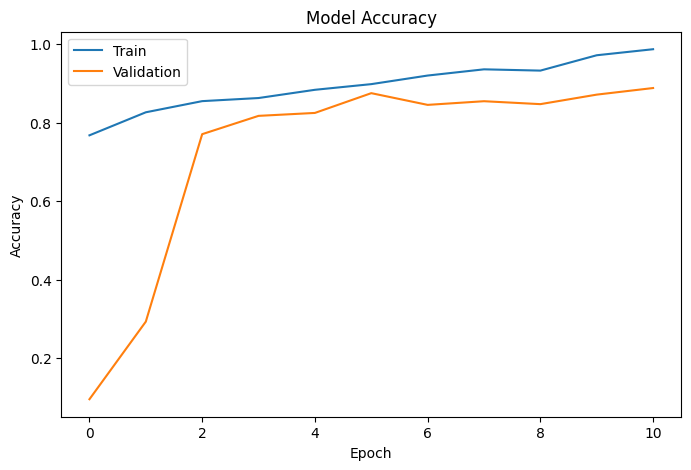

In [44]:
# ref - https://stackoverflow.com/questions/29188757/matplotlib-specify-format-of-floats-for-tick-lables
plt.figure(figsize=(8,5))

plt.plot(history_finetunning['accuracy'])
plt.plot(history_finetunning['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.gca().ticklabel_format(axis='both', style='plain', useOffset=False)
plt.show()

### <font color='red'> 9.4 Generate Train Predictions on complete Train Data </font>

In [45]:
complete_datagen = ImageDataGenerator(rescale=1./255)
complete_generator = complete_datagen.flow_from_dataframe(dataframe=df_train,
                                                          directory = "./train_images_resized_preprocessed/",
                                                          x_col="file_name",
                                                          target_size=(HEIGHT, WIDTH),
                                                          batch_size=1,
                                                          shuffle=False,
                                                          class_mode=None)

STEP_SIZE_COMPLETE = complete_generator.n//complete_generator.batch_size
train_preds = model.predict(complete_generator, steps=STEP_SIZE_COMPLETE,verbose = 1)
train_preds = [np.argmax(pred) for pred in train_preds]

Found 2693 validated image filenames.
2693/2693 [==============================] - 57s 20ms/step


In [46]:
print("Train Cohen Kappa score: %.3f" % cohen_kappa_score(train_preds, df_train['diagnosis'].astype('int'), weights='quadratic'))
print("Train Accuracy score : %.3f" % accuracy_score(df_train['diagnosis'].astype('int'),train_preds))

Train Cohen Kappa score: 0.954
Train Accuracy score : 0.925


### <font color='red'> 9.5 Evaluate Model on Test Data </font>

In [47]:
test_generator.reset()
STEP_SIZE_TEST = test_generator.n//test_generator.batch_size
test_preds = model.predict(test_generator, steps=STEP_SIZE_TEST,verbose = 1)
test_labels = [np.argmax(pred) for pred in test_preds]

674/674 [==============================] - 210s 311ms/step


In [48]:
def plot_conf_matrix(true,pred,classes):
    cf = confusion_matrix(true, pred)

    df_cm = pd.DataFrame(cf, range(len(classes)), range(len(classes)))
    plt.figure(figsize=(8,5.5))
    sns.set(font_scale=1.4)
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16},xticklabels = classes ,yticklabels = classes,fmt='g')
    #sns.heatmap(df_cm, annot=True, annot_kws={"size": 16})
    plt.show()

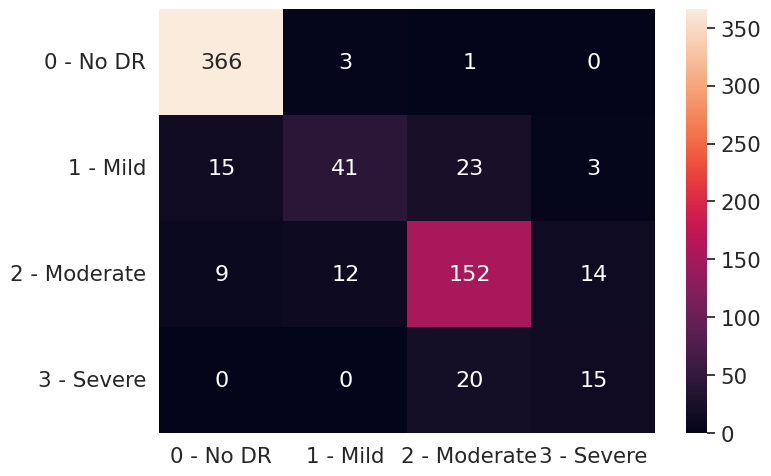

In [50]:
labels = ['0 - No DR', '1 - Mild', '2 - Moderate', '3 - Severe']
plot_conf_matrix(list(df_test['diagnosis'].astype(int)),test_labels, labels)

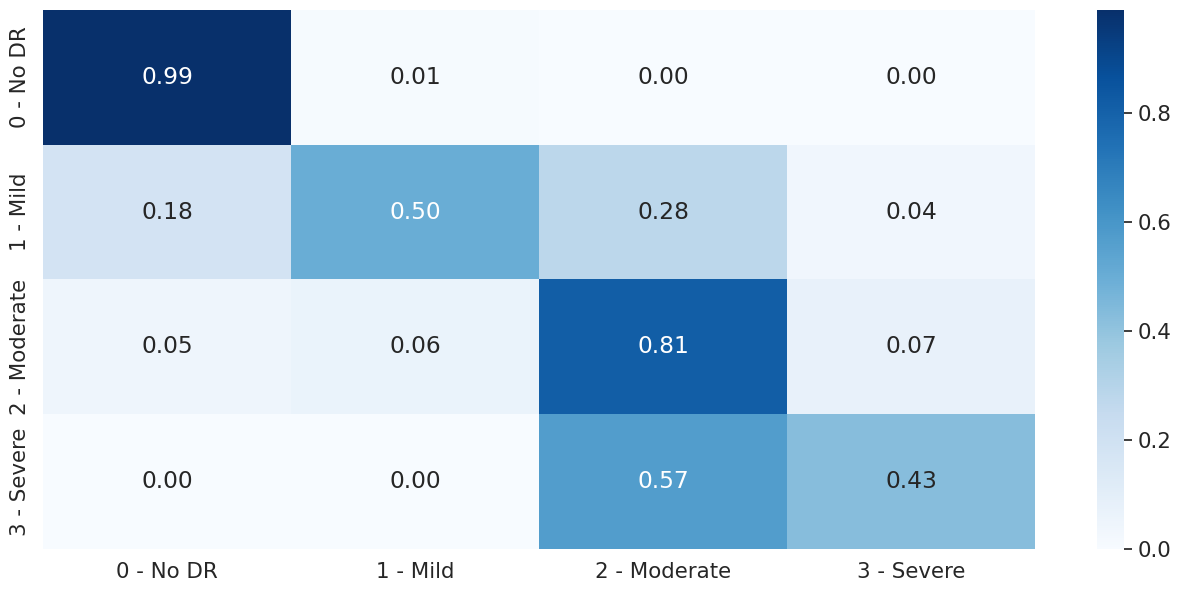

In [51]:
cnf_matrix = confusion_matrix(df_test['diagnosis'].astype('int'), test_labels)
cnf_matrix_norm = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis]
df_cm = pd.DataFrame(cnf_matrix_norm, index=labels, columns=labels)
plt.figure(figsize=(16, 7))
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap="Blues")
plt.show()

In [52]:
print("Test Cohen Kappa score: %.3f" % cohen_kappa_score(test_labels, df_test['diagnosis'].astype('int'), weights='quadratic'))
print("Test Accuracy score : %.3f" % accuracy_score(df_test['diagnosis'].astype('int'),test_labels))

Test Cohen Kappa score: 0.898
Test Accuracy score : 0.852


### <font color='red'> 9.6 ResNet50 Models Summary </font>

In [53]:
x = PrettyTable()
x.field_names = ["S.No.","ResNet50 Model","Image Processing","Data Augmentation","Hyperparameters(BS,Opt,lr,ep)","Train QWK","Test QWK"]

x.add_row([1,"R-P-D-p(0.5)-D-p(0.5)-S(5)","--","Hor Flip,Scale 1/255","(4,'Adam','1e-4',7)","0.912","0.905"])
x.add_row([2,"R-P-D-p(0.5)-D-p(0.5)-S(5)","Circle Crop, Gaussian Blur","Hor Flip,Scale 1/255","(4,'Adam','1e-4',7)","0.98","0.904"])

print(x)

+-------+----------------------------+----------------------------+----------------------+-------------------------------+-----------+----------+
| S.No. |       ResNet50 Model       |      Image Processing      |  Data Augmentation   | Hyperparameters(BS,Opt,lr,ep) | Train QWK | Test QWK |
+-------+----------------------------+----------------------------+----------------------+-------------------------------+-----------+----------+
|   1   | R-P-D-p(0.5)-D-p(0.5)-S(5) |             --             | Hor Flip,Scale 1/255 |      (4,'Adam','1e-4',7)      |   0.912   |  0.905   |
|   2   | R-P-D-p(0.5)-D-p(0.5)-S(5) | Circle Crop, Gaussian Blur | Hor Flip,Scale 1/255 |      (4,'Adam','1e-4',7)      |    0.98   |  0.904   |
+-------+----------------------------+----------------------------+----------------------+-------------------------------+-----------+----------+
